# PART 1 : Neural Network Fundamentals and Training Behavior Analysis


## Part 1 : Data Understand


Impot the Liberaries required

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
#Upload the data set

df = pd.read_csv('customer_churn_nn.csv')

Basic Exploration

In [5]:
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [6]:
#No of rows and columns

df.shape

(2000, 17)

In [7]:
#column names

df.columns

Index(['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='object')

In [8]:
#Data Type

df.dtypes

,0
customer_id,object
region,object
plan_type,object
contract_type,object
payment_method,object
tenure_months,int64
monthly_charges_inr,float64
avg_login_days_per_month,int64
support_tickets_last_90_days,int64
payment_delay_days,int64


In [9]:
# Missing Value Check

df.isnull().sum()

,0
customer_id,0
region,0
plan_type,0
contract_type,0
payment_method,0
tenure_months,0
monthly_charges_inr,0
avg_login_days_per_month,0
support_tickets_last_90_days,0
payment_delay_days,0


In [10]:

#Statistical Summary

df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


In [11]:
#Distribution of target variable

df['churn'].value_counts()

,count
churn,
0,1969
1,31


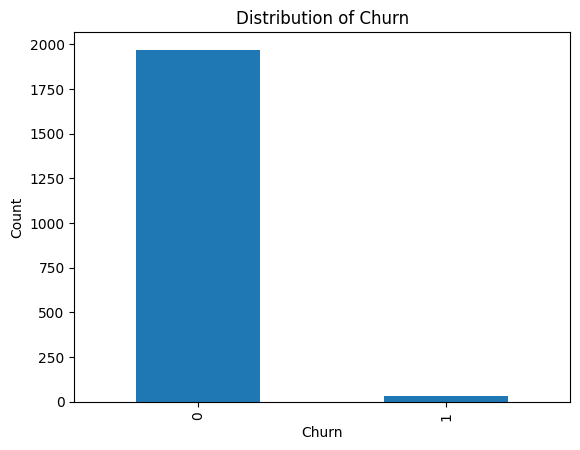

In [12]:
#Visualize Target Distribution

df['churn'].value_counts().plot(kind='bar')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Distribution of Churn')
plt.show()

# Task 2 : Data Pre pocessing

In [13]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [14]:
df = pd.read_csv('customer_churn_nn.csv')

Handling Missing Values if any

In [15]:
df.isnull().sum()

,0
customer_id,0
region,0
plan_type,0
contract_type,0
payment_method,0
tenure_months,0
monthly_charges_inr,0
avg_login_days_per_month,0
support_tickets_last_90_days,0
payment_delay_days,0


In [16]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [17]:
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [18]:
df.select_dtypes(include='object').columns

Index(['customer_id', 'region', 'plan_type', 'contract_type',
       'payment_method'],
      dtype='object')

Encoding categorical columns

In [19]:
label_encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = label_encoder.fit_transform(df[col])

In [20]:
X = df.drop('churn', axis=1)

y = df['churn']

Scaling or normalizing numerical features


In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Splitting the dataset into training and testing sets


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

## Task 3 : Neural Network Model Building

In [23]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [24]:
#Building Neural Network

model = Sequential([

    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),

    Dense(8, activation='relu'),

    Dense(1, activation='sigmoid')
])

Understanding the Architecture

In [25]:
#input Layer

input_shape=(X_train.shape[1],)

In [26]:
#Hidden layer

Dense(16, activation='relu')

<Dense name=dense_3, built=False>

In [27]:
#Activation Function

activation='relu'

In [28]:
#Output layer

Dense(1, activation='sigmoid')

<Dense name=dense_4, built=False>

In [29]:
#Compile the model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [30]:
optimizer='adam'

In [31]:
loss='binary_crossentropy'

###Train The Model

In [32]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2602 - loss: 1.0386 - val_accuracy: 0.5094 - val_loss: 0.7333
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6992 - loss: 0.5870 - val_accuracy: 0.8875 - val_loss: 0.4205
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9406 - loss: 0.3503 - val_accuracy: 0.9719 - val_loss: 0.2537
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9836 - loss: 0.2201 - val_accuracy: 0.9781 - val_loss: 0.1690
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1524 - val_accuracy: 0.9781 - val_loss: 0.1294
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.1191 - val_accuracy: 0.9781 - val_loss: 0.1107
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.1008 - val_accuracy: 0.9781 - val_loss: 0.1008
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0905 - val_accuracy: 0.9781 - val_loss:

View Model

In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,253 (4.90 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 836 (3.27 KB)

Evaluate Model

In [34]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9825 - loss: 0.0807  
Loss: 0.08073819428682327
Accuracy: 0.9825000166893005


## Task 4 : Training & Evaluation

In [35]:
#Train the Model

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0592 - val_accuracy: 0.9781 - val_loss: 0.0832
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0582 - val_accuracy: 0.9781 - val_loss: 0.0835
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0571 - val_accuracy: 0.9781 - val_loss: 0.0834
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0560 - val_accuracy: 0.9781 - val_loss: 0.0836
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0552 - val_accuracy: 0.9781 - val_loss: 0.0836
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0543 - val_accuracy: 0.9781 - val_loss: 0.0837
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0534 - val_accuracy: 0.9781 - val_loss: 0.0839
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0524 - val_accuracy: 0.9781 - val_loss:

In [36]:
#Training Accuracy & Loss

train_loss = history.history['loss'][-1]

train_accuracy = history.history['accuracy'][-1]

print("Training Loss:", train_loss)
print("Training Accuracy:", train_accuracy)

Training Loss: 0.04356202483177185
Training Accuracy: 0.9867187738418579


In [37]:
#Evaluate on test data

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Testing Loss:", test_loss)
print("Testing Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9825 - loss: 0.0752 
Testing Loss: 0.07524845004081726
Testing Accuracy: 0.9825000166893005


In [38]:
#Predictions

y_pred = model.predict(X_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [39]:
#Convert probability in 0 & 1

y_pred = (y_pred > 0.5)

Confusion Matrix

In [40]:


from sklearn.metrics import confusion_matrix

In [41]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[393   0]
 [  7   0]]


Classification Report

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



Plot Accuracy Graph

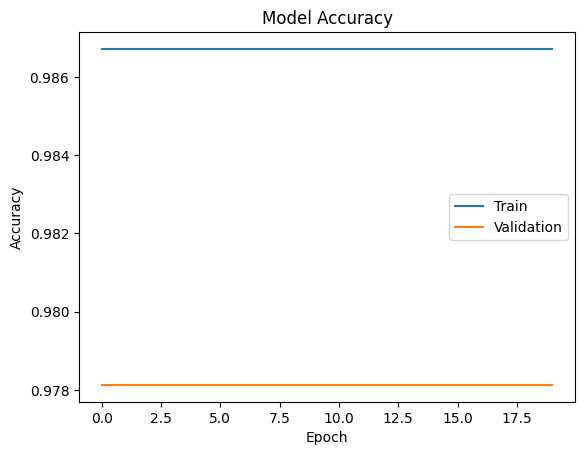

In [43]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

Plot Loss Graph

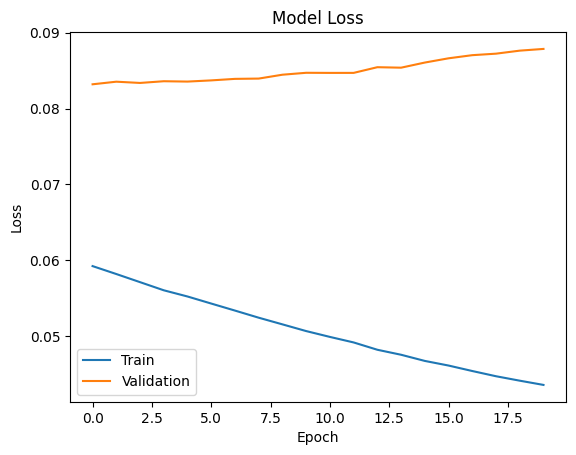

In [44]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

##Task 5: Hyperparameter Experimentation

Experiment 1 - Base Line Model

In [45]:
model1 = Sequential([

    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),

    Dense(8, activation='relu'),

    Dense(1, activation='sigmoid')
])

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss1, accuracy1 = model1.evaluate(X_test, y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9825 - loss: 0.0839  


Experiment 2 - More Neurons

In [46]:
model2 = Sequential([

    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss2, accuracy2 = model2.evaluate(X_test, y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9825 - loss: 0.0744  


Experiment 3 - Different Activation & More Epochs

In [47]:
model3 = Sequential([

    Dense(16, activation='tanh', input_shape=(X_train.shape[1],)),

    Dense(8, activation='tanh'),

    Dense(1, activation='sigmoid')
])

model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss3, accuracy3 = model3.evaluate(X_test, y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9825 - loss: 0.0661  


Comparison

In [48]:
results = pd.DataFrame({

    'Experiment': [
        'Baseline Model',
        'More Neurons',
        'Tanh + More Epochs'
    ],

    'Hidden Layers': [
        '16 → 8',
        '32 → 16',
        '16 → 8'
    ],

    'Activation': [
        'ReLU',
        'ReLU',
        'Tanh'
    ],

    'Epochs': [
        20,
        20,
        40
    ],

    'Batch Size': [
        32,
        32,
        32
    ],

    'Test Accuracy': [
        accuracy1,
        accuracy2,
        accuracy3
    ],

    'Test Loss': [
        loss1,
        loss2,
        loss3
    ]
})

print(results)

           Experiment Hidden Layers Activation  Epochs  Batch Size  \
0      Baseline Model        16 → 8       ReLU      20          32   
1        More Neurons       32 → 16       ReLU      20          32   
2  Tanh + More Epochs        16 → 8       Tanh      40          32   

   Test Accuracy  Test Loss  
0         0.9825   0.083895  
1         0.9825   0.074367  
2         0.9825   0.066093  


In [49]:
results.to_csv('model_comparison_table.csv', index=False)